In [188]:
import matplotlib.pyplot as plt
import ast
import pandas as pd
import numpy as np
import cnn_surgery.utils.metrics as metrics

In [189]:
DATASET = 'cifar10'
file_path = f'./../{DATASET}_improve_loss.csv'
df = pd.read_csv(file_path)

In [190]:
df.steps.max()

1499

In [191]:
# filters
df_filtered = df
df_filtered = df[~df['original_accuracy'].apply(lambda x: 0.0 in ast.literal_eval(x))]
df_filtered = df_filtered[~df_filtered.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']] > 0.9, axis=1)]
#df_filtered = df_filtered[~df_filtered.apply(lambda row: np.mean(ast.literal_eval(row['original_accuracy'])) < 0.7, axis=1)]
df_filtered = df_filtered[~(df_filtered['distance_travelled'] < 1.0)]
df_filtered = df_filtered[~(df_filtered['steps'] == 1499)]
df = df_filtered

In [192]:
df['target_accuracy_before'] = df.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']], axis=1)
df['target_accuracy_after'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)
df['target_accuracy_fa'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_fa'])[row['target_class']], axis=1)
df['target_accuracy_fr'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_fr'])[row['target_class']], axis=1)

df['relative_target_accuracy_after'] = df['target_accuracy_after'] / df['target_accuracy_before']
df['relative_target_accuracy_rv'] = df['target_accuracy_rv'] / df['target_accuracy_before']
df['relative_target_accuracy_fa'] = df['target_accuracy_fa'] / df['target_accuracy_before']
df['relative_target_accuracy_fr'] = df['target_accuracy_fr'] / df['target_accuracy_before']


df['mean_retain_accuracy_before'] = df.apply(lambda row: np.mean([ast.literal_eval(row['original_accuracy'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_after'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_rv'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_rv'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_fa'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_fa'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_fr'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_fr'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)

df['relative_mean_retain_accuracy_after'] = df['mean_retain_accuracy_after'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_rv'] = df['mean_retain_accuracy_rv'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_fa'] = df['mean_retain_accuracy_fa'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_fr'] = df['mean_retain_accuracy_fr'] / df['mean_retain_accuracy_before']

<Axes: >

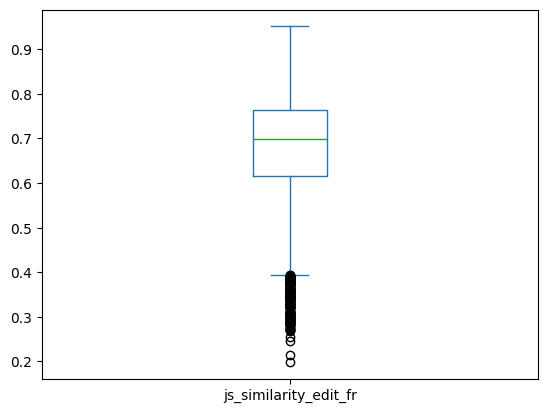

In [193]:
df.js_similarity_edit_fr.plot.box()

In [194]:
groups = df.groupby('dataset')
tables = {}
relative = False

if relative:
    relative = 'relative_'
else:
    relative = ''

for group in groups:
    target_class, group_df = group  # Unpack the tuple
    table = pd.DataFrame({
        'before': {
            'target': group_df['target_accuracy_before'].median(),
            'control': group_df['mean_retain_accuracy_before'].median(),
        },
        'Retain FT': {
            'target': group_df[relative + 'target_accuracy_fr'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_fr'].median(),
        },
        'Gradient Ascent': {
            'target': group_df[relative + 'target_accuracy_fa'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_fa'].median(),
        },
        'Random Vector': {
            'target': group_df[relative + 'target_accuracy_rv'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_rv'].median(),
        },
        'Our Method': {
            'target': group_df[relative + 'target_accuracy_after'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_after'].median(),
        },
    })
    tables[str(target_class) + f' ({len(group_df)})'] = table

In [195]:
for table in tables:
    tables[table].drop(columns=['Gradient Ascent', 'Retain FT'], inplace=True)
    print(f'Target Class: {table}')
    print(tables[table].T.round(2))

Target Class: cifar10 (8841)
               target  control
before           0.36     0.34
Random Vector    0.18     0.24
Our Method       0.61     0.19


In [196]:
print(tables[table].T.round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrr}
\toprule
 & target & control \\
\midrule
before & 0.36 & 0.34 \\
Random Vector & 0.18 & 0.24 \\
Our Method & 0.61 & 0.19 \\
\bottomrule
\end{tabular}



In [197]:
print(df.target_accuracy_before.mean())
print(df.mean_retain_accuracy_before.mean())

0.34139407306865743
0.3338736316907338


In [198]:
df['target_over_overall'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1) / df['overall_accuracy']
df['target_over_overall_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1) / df['overall_accuracy_rv']
df['mean_rest_acc'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after'])) if i != row['target_class']]), axis=1)
df['mean_rest_acc_rv'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after_rv'])) if i != row['target_class']]), axis=1)
df['avg_retain_accuracy'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['avg_retain_accuracy_rv'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
# calculate metrics
df['max_difference'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['mean_difference'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
#df['relative_clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['relative_target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['relative_target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
df['target_accuracy'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
# metrics for rv
df['max_difference_rv'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['mean_difference_rv'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['clipped_negative_mean_difference_rv'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)

In [199]:
df.target_accuracy.mean()
df.mean_rest_acc.mean()

0.18603777853184028

In [200]:
for col in df.columns:
    if 'fa' in col: print(col)

accuracy_after_fa
overall_accuracy_fa
target_accuracy_fa
relative_target_accuracy_fa
mean_retain_accuracy_fa
relative_mean_retain_accuracy_fa


In [201]:
df

,model_idx,original_accuracy,original_overall_accuracy,accuracy_after,overall_accuracy,target_class,dataset,lr,stop_threshold,l2_penalty,...,mean_difference,clipped_negative_mean_difference,target_difference,relative_target_difference,relative_target_difference_rv,target_accuracy,max_difference_rv,mean_difference_rv,clipped_negative_mean_difference_rv,target_difference_rv
1,1,"[0.42, 0.566, 0.329, 0.134, 0.323, 0.372, 0.55...",0.4169,"[0.198, 0.413, 0.031, 0.38, 0.525, 0.008, 0.59...",0.2674,0,cifar10,0.1,0.9,0.0,...,0.080556,0.026444,0.222,0.528571,0.378571,0.198,-0.209,0.098556,0.070222,0.159
2,2,"[0.356, 0.647, 0.258, 0.158, 0.374, 0.541, 0.7...",0.4681,"[0.465, 0.002, 0.255, 0.006, 0.002, 0.757, 0.0...",0.2197,0,cifar10,0.1,0.9,0.0,...,-0.397111,-0.312111,-0.109,-0.306180,1.000000,0.465,-0.185,0.083778,0.083778,0.356
3,3,"[0.376, 0.575, 0.225, 0.019, 0.3, 0.584, 0.564...",0.3776,"[0.0, 0.997, 0.0, 0.0, 0.0, 0.0, 0.024, 0.05, ...",0.1079,0,cifar10,0.1,0.9,0.0,...,0.118111,0.071222,0.376,1.000000,0.986702,0.000,-0.193,0.165111,0.066556,0.371
4,4,"[0.4, 0.275, 0.18, 0.012, 0.486, 0.266, 0.18, ...",0.2658,"[0.72, 0.309, 0.058, 0.0, 0.489, 0.0, 0.037, 0...",0.2137,0,cifar10,0.1,0.9,0.0,...,-0.413444,-0.097556,-0.320,-0.800000,-0.327500,0.720,-0.306,-0.160333,-0.077889,-0.131
5,5,"[0.445, 0.569, 0.423, 0.28, 0.314, 0.433, 0.57...",0.4671,"[0.003, 0.004, 0.0, 0.0, 0.009, 0.165, 0.255, ...",0.1377,0,cifar10,0.1,0.9,0.0,...,0.125111,0.093444,0.442,0.993258,0.988764,0.003,-0.178,0.236333,0.209889,0.440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15029,1488,"[0.454, 0.356, 0.088, 0.268, 0.3, 0.404, 0.203...",0.3131,"[0.351, 0.149, 0.083, 0.391, 0.496, 0.238, 0.0...",0.2906,9,cifar10,0.1,0.9,0.0,...,-0.190556,-0.080556,-0.149,-0.316348,-0.299363,0.620,-0.254,-0.158667,-0.036889,-0.141
15030,1489,"[0.374, 0.614, 0.231, 0.214, 0.228, 0.509, 0.7...",0.4431,"[0.008, 0.026, 0.008, 0.013, 0.0, 0.0, 0.958, ...",0.1943,9,cifar10,0.1,0.9,0.0,...,-0.313111,-0.301333,-0.033,-0.073497,-0.561247,0.482,-0.815,-0.422333,-0.195000,-0.252
15034,1493,"[0.241, 0.568, 0.28, 0.043, 0.411, 0.455, 0.56...",0.4241,"[0.0, 0.0, 0.0, 0.303, 0.005, 0.304, 0.843, 0....",0.2396,9,cifar10,0.1,0.9,0.0,...,-0.526111,-0.297444,-0.289,-0.512411,0.849291,0.853,-0.182,0.385778,0.266889,0.479
15035,1494,"[0.301, 0.565, 0.17, 0.046, 0.288, 0.458, 0.63...",0.3866,"[0.16, 0.004, 0.001, 0.059, 0.282, 0.473, 0.69...",0.2803,9,cifar10,0.1,0.9,0.0,...,-0.312556,-0.147889,-0.175,-0.387168,0.767699,0.627,-0.086,0.283444,0.212778,0.347


<Axes: ylabel='Frequency'>

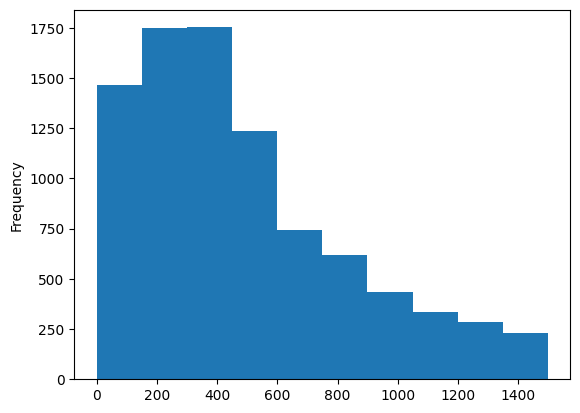

In [202]:
df.steps.plot.hist()